# Student Performance: Machine Learning


## Aim
Build a linear regression model to predict `Exam_Score` using all 19 available predictors and assess their predictive importance.

## Why linear regression?
Exam score is a numerical outcome, making this a regression task. Linear regression provides an interpretable starting point for examining how multiple predictors relate to exam performance.

## Plan
1. Load the cleaned dataset and check its structure.
2. Separate the 19 predictors from the target, `Exam_Score`.
3. Split the data into training and test sets.
4. Prepare numerical and categorical predictors using a preprocessing pipeline.
5. Train linear regression and compare it with a baseline prediction.
6. Evaluate performance using MAE, RMSE and R².
7. Calculate permutation importance on the test set for all 19 predictors.
8. Export the importance results for the Power BI dashboard.

## Interpretation
Predictive importance describes how much the trained model relies on each factor. It does not establish that a factor causes changes in exam scores.

In [1]:
from pathlib import Path
import pandas as pd

# Pathlib documentation: working with file and folder paths.
# https://docs.python.org/3/library/pathlib.html

# Locate the project root from either the project or notebook folder.
project_root = Path.cwd()
if project_root.name == "jupyter_notebooks":
    project_root = project_root.parent

# Load the cleaned CSV file into a pandas DataFrame.
data_path = project_root / "data" / "processed" / "StudentPerformanceFactors_cleaned.csv"
df = pd.read_csv(data_path)

# Display the number of rows and columns.
print("Dataset shape:", df.shape)

# Count missing values across all columns.
print("Remaining missing values:", df.isna().sum().sum())

# Preview the first five rows.
df.head()

Dataset shape: (6607, 20)
Remaining missing values: 0


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Reference: pandas documentation for DataFrame.drop:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html
# Code generated with ChatGPT assistance and adapted for this project.
# X contains all 19 predictors; y contains the exam score to predict.
# Help: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

print("Predictors:", X.shape)
print("Target:", y.shape)

Predictors: (6607, 19)
Target: (6607,)


## Training and Test Split

The dataset was randomly split into two sets:

- **Training set:** 5,285 rows (80%), used to fit the model.
- **Test set:** 1,322 rows (20%), reserved for evaluating predictions on unseen data.

Both sets contain all 19 predictors. `Exam_Score` is the target variable.

Setting `random_state=42` makes the split reproducible. Preprocessing will be fitted on the training set and then applied to the test set.

In [4]:
# Reference: scikit-learn documentation for train_test_split:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Code generated with ChatGPT assistance and adapted for this project.

from sklearn.model_selection import train_test_split

# Reserve 20% of the data for testing and use 80% for training.
# random_state=42 makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5285, 19)
Test set: (1322, 19)


In [5]:
# Reference: pandas documentation for DataFrame.select_dtypes:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html
# Code generated with ChatGPT assistance and adapted for this project.

# Identify numerical and categorical predictors in the training data.
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numerical predictors:", len(numeric_features))
print(numeric_features)

print("\nCategorical predictors:", len(categorical_features))
print(categorical_features)

Numerical predictors: 6
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical predictors: 13
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## Predictor Types

The model uses six numerical predictors and thirteen categorical predictors.

- **Numerical predictors** will be standardised to put them on a common scale.
- **Categorical predictors** will be one-hot encoded into numerical indicator columns. This avoids assuming equal spacing between categories such as Low, Medium and High.

Scaling and encoding will be fitted using only the training data, then applied to the test data through a preprocessing pipeline.

The final importance analysis will report results for the original 19 predictors, grouping each categorical variable's encoded columns together.

In [6]:
# References: scikit-learn preprocessing documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
# Code generated with ChatGPT assistance and adapted for this project.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define how each predictor type will be prepared.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created. It has not yet been fitted.")

Preprocessor created. It has not yet been fitted.


## Connecting Preprocessing to Linear Regression

The preprocessor has been defined but has not yet learned anything from the data.

The next step combines it with linear regression in a single pipeline. When fitted, the pipeline will:

1. Learn scaling parameters for the numerical predictors from the training data.
2. Learn and encode the categorical predictors from the training data.
3. Train linear regression using the transformed predictors and their corresponding exam scores.

The test set remains separate for evaluating the model.

In [7]:
# References: scikit-learn documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
# Code generated with ChatGPT assistance and adapted for this project.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Combine preprocessing and linear regression in one pipeline.
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Fit preprocessing and the model using only the training data.
model.fit(X_train, y_train)

print("Linear regression model trained successfully.")

Linear regression model trained successfully.


## Model Training

A linear regression model was trained using all 19 predictors through a preprocessing pipeline.

The pipeline learns numerical scaling parameters and categorical encodings from the training data, then fits the regression model. The test set is not used during fitting.

Training is complete; predictive performance will be assessed next against a baseline model.

## Baseline and Model Evaluation

The linear regression model will be compared with a simple baseline that predicts the mean training exam score for every student.

Both models will be evaluated on the same test set using:

- **MAE (Mean Absolute Error):** the average absolute prediction error, measured in exam-score points. Lower is better.
- **RMSE (Root Mean Squared Error):** prediction error in exam-score points, giving more weight to large errors. Lower is better.
- **R²:** performance relative to predicting the test-set mean. A score of 1 indicates perfect predictions; 0 matches that reference, and negative values are worse.

This comparison will show whether using the 19 predictors improves predictions over the training-mean baseline.

In [8]:
# References: scikit-learn documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html
# https://scikit-learn.org/stable/modules/model_evaluation.html
# Code generated with ChatGPT assistance and adapted for this project.

import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fit the baseline using the training target only.
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

# Predict exam scores for the same test rows.
baseline_predictions = baseline.predict(X_test)
model_predictions = model.predict(X_test)

# Calculate test metrics for both models.
results = []

for name, predictions in [
    ("Mean baseline", baseline_predictions),
    ("Linear regression", model_predictions)
]:
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R²": r2_score(y_test, predictions)
    })

evaluation_results = pd.DataFrame(results).set_index("Model")
evaluation_results.round(3)

,MAE,RMSE,R²
Model,,,
Mean baseline,2.823,3.761,-0.001
Linear regression,0.450,1.803,0.770


### Evaluation Findings

Linear regression outperformed the mean baseline on the 1,322 test rows:

- **MAE decreased from 2.823 to 0.450 points**, meaning predictions were approximately 0.45 exam-score points away from the recorded scores on average.
- **RMSE decreased from 3.761 to 1.803 points**, indicating an improvement when larger errors receive greater weight.
- **R² increased from −0.001 to 0.770**, indicating that the model explained approximately 77% of the variation in test-set exam scores.

The baseline's slightly negative R² arises because the training mean differs from the test mean.

The model's RMSE is substantially higher than its MAE, suggesting some much larger prediction errors. Residual plots will help investigate these.

These results support the predictive value of the 19 factors collectively on this test split. They do not establish causal effects or guarantee the same performance on other student populations.

## Prediction and Residual Checks

Two plots will help assess the model's test-set predictions:

1. **Actual versus predicted scores:** points close to the diagonal line represent accurate predictions.
2. **Residuals versus predicted scores:** residuals are calculated as actual score minus predicted score. Positive values indicate underprediction; negative values indicate overprediction.

Residuals should ideally be scattered around zero without a clear pattern. Large residuals identify students whose scores the model predicted poorly.

These checks will help explain why RMSE is substantially higher than MAE.


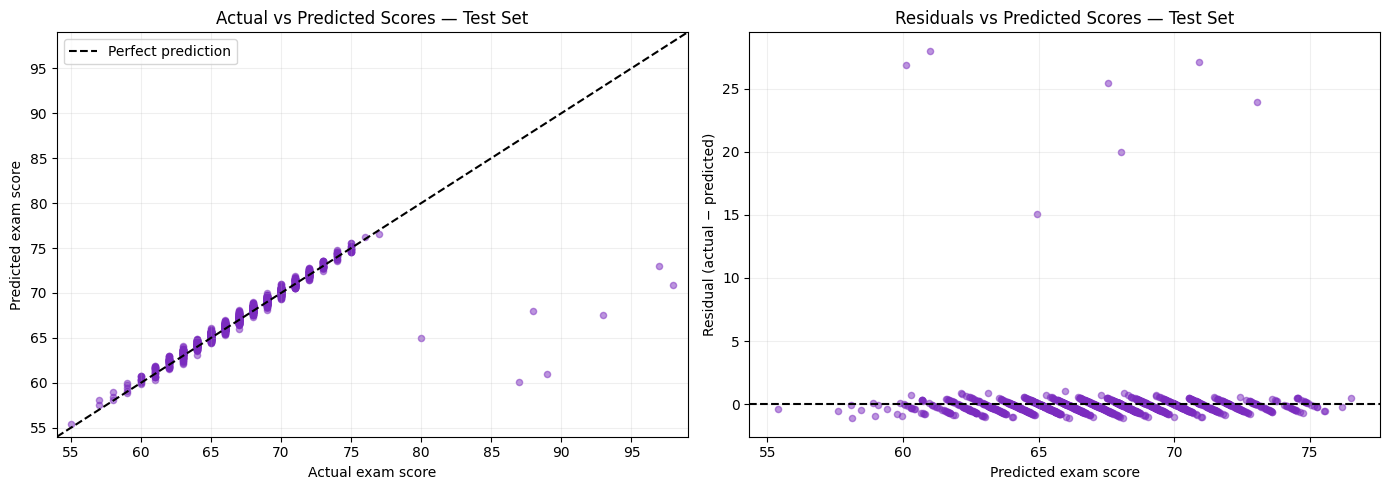

In [10]:
# References: Matplotlib documentation:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html
# Code generated with ChatGPT assistance and adapted for this project.

%matplotlib inline
import matplotlib.pyplot as plt

# Positive residuals mean the model underpredicted the exam score.
residuals = y_test - model_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: actual versus predicted exam scores.
axes[0].scatter(
    y_test, model_predictions,
    color="#7B2CBF", alpha=0.5, s=20
)

# Use matching axis limits and a perfect-prediction reference line.
lower = min(y_test.min(), model_predictions.min()) - 1
upper = max(y_test.max(), model_predictions.max()) + 1

axes[0].plot(
    [lower, upper], [lower, upper],
    color="black", linestyle="--", label="Perfect prediction"
)
axes[0].set_xlim(lower, upper)
axes[0].set_ylim(lower, upper)
axes[0].set_xlabel("Actual exam score")
axes[0].set_ylabel("Predicted exam score")
axes[0].set_title("Actual vs Predicted Scores — Test Set")
axes[0].legend()

# Plot 2: residuals versus predicted exam scores.
axes[1].scatter(
    model_predictions, residuals,
    color="#7B2CBF", alpha=0.5, s=20
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted exam score")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residuals vs Predicted Scores — Test Set")

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Prediction and Residual Findings

Most test observations lie close to the perfect-prediction line, with residuals concentrated near zero. This is consistent with the low MAE of 0.450 points.

However, several students with high actual scores received much lower predictions. The largest positive residuals are approximately 24–28 points, showing substantial underprediction for these observations.

These large errors explain why RMSE (1.803) is considerably higher than MAE: RMSE gives greater weight to large errors.

The diagonal bands in the residual plot arise because recorded exam scores are integers, while predictions are continuous.

The model predicts most test scores closely but does not capture all unusually high scores. Large residuals alone do not prove that those records are incorrect, so they should not be removed simply to improve performance.